In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as  plt
from sklearn.model_selection import train_test_split

In [2]:
df= pd.read_csv("loan_approval_data.csv")

df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [3]:
cat_cols= df.select_dtypes(include=["object"]).columns
num_cols= df.select_dtypes(include=["number"]).columns

In [4]:
from sklearn.impute import SimpleImputer

num_imp= SimpleImputer(strategy="mean")
df[num_cols]= num_imp.fit_transform(df[num_cols])

In [5]:
cat_imp= SimpleImputer(strategy="most_frequent")
df[cat_cols]= cat_imp.fit_transform(df[cat_cols])

In [6]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# EDA

Text(0.5, 1.0, 'Is loan approved')

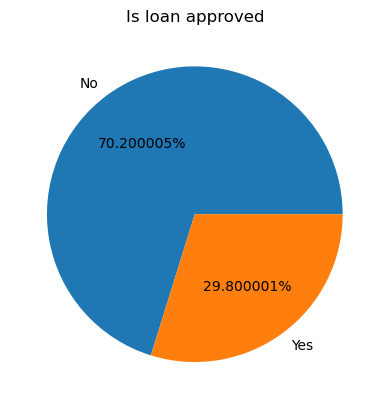

In [7]:
cl_count= df["Loan_Approved"].value_counts()

plt.pie(cl_count, labels=["No","Yes"], autopct="%1f%%")
plt.title("Is loan approved")

[Text(0, 0, '621'), Text(0, 0, '379')]

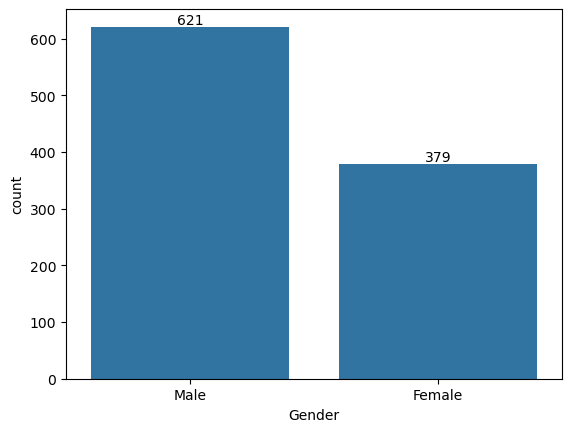

In [8]:
G_cnt= df["Gender"].value_counts()
ax= sns.barplot(G_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

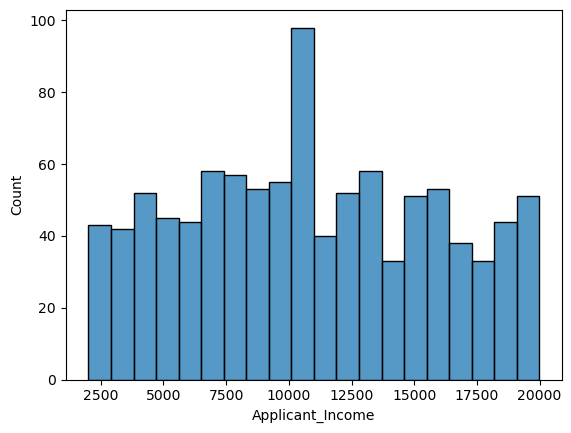

In [9]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)

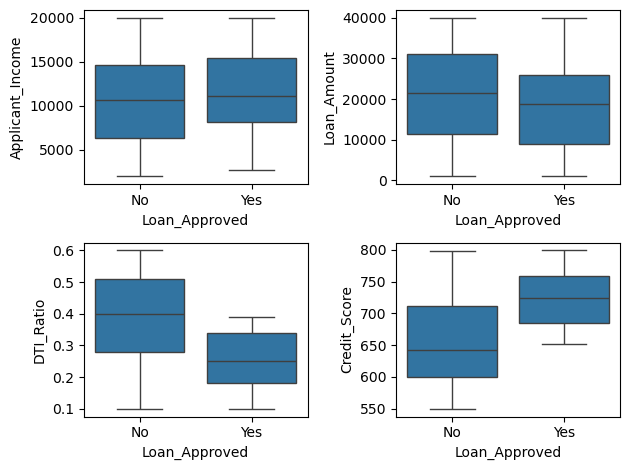

In [10]:
fig, axes= plt.subplots(2,2)

sns.boxplot(ax= axes[0,0],data=df,  x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax= axes[0,1],data=df,  x="Loan_Approved",y="Loan_Amount")
sns.boxplot(ax= axes[1,0],data=df,  x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax= axes[1,1],data=df,  x="Loan_Approved",y="Credit_Score")

plt.tight_layout()

In [11]:
# df= df.drop("Applicant_ID", axis=1)


In [12]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

# Encoding

In [13]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [14]:
le= LabelEncoder()

df["Education_Level"]= le.fit_transform(df["Education_Level"])
df["Loan_Approved"]= le.fit_transform(df["Loan_Approved"])

In [15]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

In [16]:
cols= ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

ohe= OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded= ohe.fit_transform(df[cols])
encoded_df= pd.DataFrame(encoded, columns= ohe.get_feature_names_out(cols), index=df.index)

df= pd.concat([df.drop(columns=cols),encoded_df], axis=1)



In [17]:
df= df.drop("Applicant_ID", axis=1)


In [18]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


# Testing and Feature


In [21]:
X= df.drop("Loan_Approved", axis=1)
y=df["Loan_Approved"]

In [22]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [25]:
X_train, X_test, y_train, y_test, =  train_test_split(
    X,y, test_size=0.2, random_state=42
)

X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [26]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

X_trs=scaler.fit_transform(X_train)
X_tss=scaler.transform(X_test)


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, f1_score,confusion_matrix, recall_score

lm=LogisticRegression()

lm.fit(X_trs,y_train)
y_pred= lm.predict(X_tss)

print("LogiscticRegression")
print("Accuracy Score:", accuracy_score(y_test,y_pred))
print("Precision Score:", precision_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))
print("Recall Score:", recall_score(y_test,y_pred))
print("Confusion Matrix :", confusion_matrix(y_test,y_pred))



LogiscticRegression
Accuracy Score: 0.865
Precision Score: 0.7833333333333333
F1 Score: 0.7768595041322314
Recall Score: 0.7704918032786885
Confusion Matrix : [[126  13]
 [ 14  47]]


In [35]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score,confusion_matrix, recall_score

Km=KNeighborsClassifier(n_neighbors=5)

Km.fit(X_trs,y_train)
y_pred= Km.predict(X_tss)

print("KNN")
print("Accuracy Score:", accuracy_score(y_test,y_pred))
print("Precision Score:", precision_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))
print("Recall Score:", recall_score(y_test,y_pred))
print("Confusion Matrix :", confusion_matrix(y_test,y_pred))



KNN
Accuracy Score: 0.76
Precision Score: 0.6274509803921569
F1 Score: 0.5714285714285714
Recall Score: 0.5245901639344263
Confusion Matrix : [[120  19]
 [ 29  32]]


In [36]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, f1_score,confusion_matrix, recall_score

Gm=GaussianNB()

Gm.fit(X_trs,y_train)
y_pred= Gm.predict(X_tss)

print("KNN")
print("Naive Bayes:", accuracy_score(y_test,y_pred))
print("Precision Score:", precision_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))
print("Recall Score:", recall_score(y_test,y_pred))
print("Confusion Matrix :", confusion_matrix(y_test,y_pred))



KNN
Naive Bayes: 0.865
Precision Score: 0.8035714285714286
F1 Score: 0.7692307692307693
Recall Score: 0.7377049180327869
Confusion Matrix : [[128  11]
 [ 16  45]]
